# __Business Case :__

* Bank GoodCredit wants to predict cred score for current credit card customers. 
* The cred score will denote a customer’s credit worthiness and help the bank in reducing credit default risk.

* Target variable → Bad_label
* 0 – Customer has Good credit history
* 1 – Customer has Bad credit history (falls into 30 DPD + bucket)

# __Data Explanation :__

## __Customer Account Data (Table : Cust_Account) :__

* This table contains customer’s historical accounts data and payments hitory.

## __Customer Enquiry Data (Table : Cust_Enquiry) :__

* This table contains customer’s historical enquiry data such as enquiry amount and enquiry purpose.

## __Demographics Data (Table : Cust_Demographics) :__

* Current customer applications with demographic data.
  
* Note that demographics features are renamed as features and obscured in accordance with privacy policies.

# __Import Libraries :__

In [132]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [133]:
!pip install imbalanced-learn

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from imblearn.over_sampling import SMOTE
import joblib

# __Load The Data :__

In [135]:
cust_account = pd.read_csv("Cust_Account.csv")
cust_enquiry = pd.read_csv("Cust_Enquiry.csv")
cust_demo = pd.read_csv("Cust_Demographics.csv")

In [136]:
print("Customer Account Shape:", cust_account.shape)
print("Customer Enquiry Shape:", cust_enquiry.shape)
print("Customer Demographics Shape:", cust_demo.shape)

Customer Account Shape: (1000, 21)
Customer Enquiry Shape: (1000, 6)
Customer Demographics Shape: (1000, 83)


In [137]:
cust_account.head()

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900.0,0,NaN,"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD...",NaN,01-Sep-15,01-Jul-14,NaN,NaN,NaN,NaN,NaN
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,NaN,03-Oct-15,16201.0,10390,NaN,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000XXX000000000000000...",01-Oct-15,01-Nov-12,14000.0,1400.0,NaN,3.0,5603.0
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,NaN,30-Sep-15,41028.0,34420,NaN,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,NaN,NaN,NaN,NaN,NaN
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,NaN,26-Jul-07,31-Jan-09,93473.0,0,NaN,"""120090060060060030000000000000000000000000000...",NaN,01-Jul-07,01-Feb-06,NaN,NaN,NaN,NaN,NaN
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,NaN,31-May-15,20250.0,13500,NaN,"""000000000000000""""""""",NaN,01-May-15,01-Jan-15,NaN,NaN,NaN,NaN,NaN


In [138]:
cust_enquiry.head()

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2.0,3500000.0
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5.0,500000.0
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0.0,50000.0
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10.0,50000.0
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10.0,1000.0


In [139]:
cust_demo.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,159,4284,4284,NaN,1,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1,2,NaN,Mumbai / Navi Mumbai / Thane,400610,1965,0,Self,Y,2,90000,NaN,NaN,NaN,0,0,0,0,Mumbai,400059,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,NaN,Y,State Bank of India,0,01-Jun-13,17-Jun-16,1,21,NaN,Y,Y,N,NaN,Y,1965-0,21,15,400610,0,2,90000,Nov-00,21,R,NaN,NaN,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1,Card Setup,14,1200000,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077,NaN,1,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1,2,NaN,Bengaluru,560042,1969,0,Self,Y,2,1,NaN,NaN,NaN,0,0,0,0,Bangalore,560042,NaN,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0,NaN,17-Jun-16,1,17,NaN,Y,Y,N,NaN,Y,1969-0,17,12,560042,0,2,1,Nov-00,17,R,NaN,NaN,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1,Card Setup,14,700000,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077,NaN,2,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1,0,NaN,Bengaluru,560042,1966,0,Self,Y,2,1,NaN,NaN,NaN,0,0,0,0,Bangalore,560042,NaN,PAN Card,AFAPNXXXXX,NaN,NaN,N,NaN,0,NaN,17-Jun-16,3,17,NaN,N,Y,N,NaN,Y,1966-0,17,12,560042,0,2,1,Nov-00,17,R,NaN,NaN,0000-00-00,0,98456XXXXX,1,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.0,1,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,157,5107,5107,NaN,1,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1,3,NaN,Pune,411001,1988,0,Self,Y,2,100000,NaN,NaN,NaN,0,0,0,0,Pune,411026,@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.,NaN,Y,HDFC Bank,0,NaN,17-Jun-16,1,21,NaN,Y,Y,N,NaN,Y,1988-0,21,16,411001,0,2,100000,Nov-00,21,R,NaN,NaN,6/15/65,1,98220XXXXX,1,N,0
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,100,D016,4564,NaN,1,ABEPSXXXXX,03-Jan-54,98111XXXXX,N,@REDIFFMAIL.COM,1,3,NaN,Gurgaon,122009,1995,0,Self,Y,2,300000,NaN,NaN,NaN,0,0,0,0,Gurgaon,122009,NaN,PAN Card,ABEPSXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0,NaN,17-Jun-16,1,13,NaN,Y,Y,N,NaN,Y,1995-0,13,3,122009,0,2,300000,Nov-00,13,R,NaN,NaN,0000-00-00,0,98111XXXXX,1,N,0


In [140]:
cust_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   dt_opened            1000 non-null   object 
 1   customer_no          1000 non-null   int64  
 2   upload_dt            1000 non-null   object 
 3   acct_type            1000 non-null   int64  
 4   owner_indic          1000 non-null   int64  
 5   opened_dt            998 non-null    object 
 6   last_paymt_dt        863 non-null    object 
 7   closed_dt            445 non-null    object 
 8   reporting_dt         1000 non-null   object 
 9   high_credit_amt      927 non-null    float64
 10  cur_balance_amt      1000 non-null   int64  
 11  amt_past_due         5 non-null      float64
 12  paymenthistory1      1000 non-null   object 
 13  paymenthistory2      443 non-null    object 
 14  paymt_str_dt         1000 non-null   object 
 15  paymt_end_dt         1000 non-null   ob

In [141]:
cust_enquiry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dt_opened    1000 non-null   object 
 1   customer_no  1000 non-null   int64  
 2   upload_dt    999 non-null    object 
 3   enquiry_dt   999 non-null    object 
 4   enq_purpose  999 non-null    float64
 5   enq_amt      999 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 47.0+ KB


In [142]:
cust_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 83 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dt_opened    1000 non-null   object 
 1   customer_no  1000 non-null   int64  
 2   entry_time   1000 non-null   object 
 3   feature_1    1000 non-null   object 
 4   feature_2    903 non-null    object 
 5   feature_3    903 non-null    float64
 6   feature_4    1000 non-null   int64  
 7   feature_5    1000 non-null   object 
 8   feature_6    1000 non-null   int64  
 9   feature_7    1000 non-null   int64  
 10  feature_8    3 non-null      object 
 11  feature_9    3 non-null      object 
 12  feature_10   0 non-null      float64
 13  feature_11   1000 non-null   object 
 14  feature_12   1000 non-null   object 
 15  feature_13   728 non-null    object 
 16  feature_14   992 non-null    float64
 17  feature_15   999 non-null    object 
 18  feature_16   998 non-null    object 
 19  feature

In [143]:
cust_account.isnull().sum().sort_values(ascending=False)

amt_past_due           995
rateofinterest         882
cashlimit              821
actualpaymentamount    802
creditlimit            763
paymentfrequency       674
paymenthistory2        557
closed_dt              555
last_paymt_dt          137
high_credit_amt         73
opened_dt                2
paymt_end_dt             0
paymt_str_dt             0
dt_opened                0
paymenthistory1          0
customer_no              0
reporting_dt             0
owner_indic              0
acct_type                0
upload_dt                0
cur_balance_amt          0
dtype: int64

In [144]:
cust_enquiry.isnull().sum().sort_values(ascending=False)

upload_dt      1
enquiry_dt     1
enq_purpose    1
enq_amt        1
dt_opened      0
customer_no    0
dtype: int64

In [145]:
cust_demo.isnull().sum().sort_values(ascending=False)

feature_10     1000
feature_74      999
feature_61      998
feature_8       997
feature_18      997
feature_9       997
feature_57      990
feature_73      990
feature_49      986
feature_17      924
feature_48      742
feature_45      475
feature_53      379
feature_51      375
feature_13      272
feature_36      263
feature_37      263
feature_38      263
feature_27      149
feature_2        97
feature_3        97
feature_24       29
feature_46       18
feature_14        8
feature_16        2
feature_15        1
feature_58        0
feature_50        0
feature_59        0
feature_52        0
feature_56        0
feature_54        0
feature_60        0
feature_55        0
dt_opened         0
feature_62        0
feature_63        0
feature_64        0
feature_65        0
feature_66        0
feature_68        0
feature_69        0
feature_70        0
feature_71        0
feature_72        0
feature_75        0
feature_76        0
feature_77        0
feature_78        0
feature_79        0


In [146]:
cust_account.columns

Index(['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic',
       'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt',
       'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1',
       'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit',
       'cashlimit', 'rateofinterest', 'paymentfrequency',
       'actualpaymentamount'],
      dtype='object')

In [147]:
cust_enquiry.columns

Index(['dt_opened', 'customer_no', 'upload_dt', 'enquiry_dt', 'enq_purpose',
       'enq_amt'],
      dtype='object')

In [148]:
cust_demo.columns

Index(['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12',
       'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17',
       'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22',
       'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27',
       'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32',
       'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37',
       'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42',
       'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47',
       'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52',
       'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57',
       'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62',
       '

In [149]:
print("Unique customers in Account:", cust_account['customer_no'].nunique())
print("Unique customers in Enquiry:", cust_enquiry['customer_no'].nunique())
print("Unique customers in Demographics:", cust_demo['customer_no'].nunique())

Unique customers in Account: 123
Unique customers in Enquiry: 51
Unique customers in Demographics: 1000


In [150]:
# Check if customer_no matches row by row
(cust_account['customer_no'] == cust_demo['customer_no']).sum()

0

In [151]:
# Check if customer_no matches row by row
(cust_enquiry['customer_no'] == cust_demo['customer_no']).sum()

1

In [152]:
# Drop customer_no from secondary tables
cust_account_clean = cust_account.drop(columns=['customer_no'])
cust_enquiry_clean = cust_enquiry.drop(columns=['customer_no'])

# Combine all data
final_df = pd.concat([cust_demo, cust_account_clean, cust_enquiry_clean], axis=1)

In [153]:
final_df.shape

(1000, 108)

In [154]:
# for display all the columns
pd.set_option('display.max_columns', None)
final_df.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label,dt_opened,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount,dt_opened,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,159,4284,4284,NaN,1,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1,2,NaN,Mumbai / Navi Mumbai / Thane,400610,1965,0,Self,Y,2,90000,NaN,NaN,NaN,0,0,0,0,Mumbai,400059,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,NaN,Y,State Bank of India,0,01-Jun-13,17-Jun-16,1,21,NaN,Y,Y,N,NaN,Y,1965-0,21,15,400610,0,2,90000,Nov-00,21,R,NaN,NaN,0000-00-00,0,98332XXXXX,1,N,0,10-Nov-15,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900.0,0,NaN,"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD...",NaN,01-Sep-15,01-Jul-14,NaN,NaN,NaN,NaN,NaN,18-Apr-15,21-Apr-15,19-Dec-14,2.0,3500000.0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1,Card Setup,14,1200000,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077,NaN,1,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1,2,NaN,Bengaluru,560042,1969,0,Self,Y,2,1,NaN,NaN,NaN,0,0,0,0,Bangalore,560042,NaN,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,NaN,N,NaN,0,NaN,17-Jun-16,1,17,NaN,Y,Y,N,NaN,Y,1969-0,17,12,560042,0,2,1,Nov-00,17,R,NaN,NaN,0000-00-00,0,99455XXXXX,1,N,0,10-Nov-15,20-Oct-15,10,1,25-May-12,06-Sep-15,NaN,03-Oct-15,16201.0,10390,NaN,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000XXX000000000000000...",01-Oct-15,01-Nov-12,14000.0,1400.0,NaN,3.0,5603.0,18-Apr-15,21-Apr-15,05-Mar-14,5.0,500000.0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1,Card Setup,14,700000,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077,NaN,2,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1,0,NaN,Bengaluru,560042,1966,0,Self,Y,2,1,NaN,NaN,NaN,0,0,0,0,Bangalore,560042,NaN,PAN Card,AFAPNXXXXX,NaN,NaN,N,NaN,0,NaN,17-Jun-16,3,17,NaN,N,Y,N,NaN,Y,1966-0,17,12,560042,0,2,1,Nov-00,17,R,NaN,NaN,0000-00-00,0,98456XXXXX,1,N,0,10-Nov-15,20-Oct-15,10,1,22-Mar-12,31-Aug-15,NaN,30-Sep-15,41028.0,34420,NaN,"""000000000000000000000000000000000000000000000...","""000000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,NaN,NaN,NaN,NaN,NaN,18-Apr-15,21-Apr-15,05-Mar-14,0.0,50000.0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.0,1,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,157,5107,5107,NaN,1,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1,3,NaN,Pune,411001,1988,0,Self,Y,2,100000,NaN,NaN,NaN,0,0,0,0,Pune,411026,@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.,NaN,Y,HDFC Bank,0,NaN,17-Jun-16,1,21,NaN,Y,Y,N,NaN,Y,1988-0,21,16,411001,0,2,100000,Nov-00,21,R,NaN,NaN,6/15/65,1,98220XXXXX,1,N,0,20-Jul-15,09-Jul-15,10,1,13-Jan-06,NaN,26-Jul-07,31-Jan-09,93473.0,0,NaN,"""120090060060060030000000000000000000000000000...",NaN,01-Jul-07,01-Feb-06,NaN,NaN,NaN,NaN,NaN,18-Apr-15,21-Apr-15,22-Feb-14,10.0,50000.0
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3,Card Setup,14,500000,NaN,NaN,NaN,Y,IS1,NaN,0.0,100,D

In [155]:
final_df.columns

Index(['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       ...
       'creditlimit', 'cashlimit', 'rateofinterest', 'paymentfrequency',
       'actualpaymentamount', 'dt_opened', 'upload_dt', 'enquiry_dt',
       'enq_purpose', 'enq_amt'],
      dtype='object', length=108)

In [156]:
date_cols = ['dt_opened','entry_time','feature_2','feature_21','feature_53','feature_54','dt_opened','upload_dt','enquiry_dt' ]

for col in date_cols:
    try:
        final_df[col] = pd.to_datetime(final_df[col], errors='coerce')
    except:
        pass

print("Date conversion done")

Date conversion done


In [157]:
for col in ['reporting_dt', 'opened_dt', 'last_paymt_dt', 'paymt_str_dt', 'paymt_end_dt', 'enquiry_dt']:
    print(col, "->", col in final_df.columns)

reporting_dt -> True
opened_dt -> True
last_paymt_dt -> True
paymt_str_dt -> True
paymt_end_dt -> True
enquiry_dt -> True


In [158]:
final_df[['reporting_dt', 'opened_dt']].dtypes

reporting_dt    object
opened_dt       object
dtype: object

In [159]:
# Force conversion again safely
for col in ['reporting_dt', 'opened_dt', 'last_paymt_dt', 'paymt_str_dt', 'paymt_end_dt', 'enquiry_dt']:
    if col in final_df.columns:
        final_df[col] = pd.to_datetime(final_df[col], errors='coerce')

In [160]:
# Fill missing reporting date (very important)
if 'reporting_dt' in final_df.columns:
    final_df['reporting_dt'] = final_df['reporting_dt'].fillna(method='ffill')

In [161]:
# Account age
if all(col in final_df.columns for col in ['reporting_dt', 'opened_dt']):
    final_df['account_age_days'] = (final_df['reporting_dt'] - final_df['opened_dt']).dt.days

# Days since last payment
if all(col in final_df.columns for col in ['reporting_dt', 'last_paymt_dt']):
    final_df['days_since_last_payment'] = (final_df['reporting_dt'] - final_df['last_paymt_dt']).dt.days

# Payment duration
if all(col in final_df.columns for col in ['paymt_end_dt', 'paymt_str_dt']):
    final_df['payment_duration'] = (final_df['paymt_end_dt'] - final_df['paymt_str_dt']).dt.days

# Enquiry recency
if all(col in final_df.columns for col in ['reporting_dt', 'enquiry_dt']):
    final_df['days_since_enquiry'] = (final_df['reporting_dt'] - final_df['enquiry_dt']).dt.days

In [162]:
final_df[['account_age_days', 'days_since_last_payment','payment_duration','days_since_enquiry']].head()

,account_age_days,days_since_last_payment,payment_duration,days_since_enquiry
0,843.0,457.0,-427,285.0
1,1226.0,27.0,-1064,577.0
2,1287.0,30.0,-1065,574.0
3,1114.0,NaN,-515,-1848.0
4,133.0,26.0,-120,719.0


In [163]:
final_df.isnull().sum().sort_values(ascending=False)

feature_10                 1000
feature_74                  999
feature_61                  998
feature_8                   997
feature_18                  997
feature_9                   997
amt_past_due                995
feature_73                  990
feature_57                  990
feature_49                  986
feature_17                  924
rateofinterest              882
cashlimit                   821
actualpaymentamount         802
creditlimit                 763
feature_48                  742
paymentfrequency            674
paymenthistory2             557
closed_dt                   555
feature_45                  475
feature_53                  379
feature_51                  375
feature_13                  272
feature_36                  263
feature_38                  263
feature_37                  263
feature_27                  149
last_paymt_dt               137
days_since_last_payment     137
feature_3                    97
feature_2                    97
high_cre

In [164]:
missing_df = pd.DataFrame({
    'column': final_df.columns,
    'missing_count': final_df.isnull().sum(),
    'missing_percent': (final_df.isnull().sum() / len(final_df)) * 100
}).sort_values(by='missing_percent', ascending=False)

missing_df

,column,missing_count,missing_percent
feature_10,feature_10,1000,100.0
feature_74,feature_74,999,99.9
feature_61,feature_61,998,99.8
feature_8,feature_8,997,99.7
feature_18,feature_18,997,99.7
feature_9,feature_9,997,99.7
amt_past_due,amt_past_due,995,99.5
feature_73,feature_73,990,99.0
feature_57,feature_57,990,99.0
feature_49,feature_49,986,98.6


In [165]:
cols_to_drop = ['entry_time','feature_10','feature_74','feature_61','feature_8','feature_18','feature_9','amt_past_due','feature_73','feature_57','feature_49',
               'feature_17','rateofinterest','actualpaymentamount','feature_48']
final_df = final_df.drop(columns=cols_to_drop)

In [166]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 97 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dt_opened                1000 non-null   object        
 1   customer_no              1000 non-null   int64         
 2   feature_1                1000 non-null   object        
 3   feature_2                903 non-null    datetime64[ns]
 4   feature_3                903 non-null    float64       
 5   feature_4                1000 non-null   int64         
 6   feature_5                1000 non-null   object        
 7   feature_6                1000 non-null   int64         
 8   feature_7                1000 non-null   int64         
 9   feature_11               1000 non-null   object        
 10  feature_12               1000 non-null   object        
 11  feature_13               728 non-null    object        
 12  feature_14               992 non-nu

In [167]:
date_cols = ['dt_opened', 'opened_dt', 'last_paymt_dt', 'closed_dt','reporting_dt', 'paymt_str_dt', 'paymt_end_dt', 'enquiry_dt', 'upload_dt',
            'feature_2','feature_21','feature_53','feature_54']

date_cols = [col for col in date_cols if col in final_df.columns]

final_df = final_df.drop(columns=date_cols)

In [168]:
num_cols = final_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = final_df.select_dtypes(include=['object']).columns

In [169]:
num_cols = num_cols.drop('Bad_label', errors='ignore')
cat_cols = cat_cols.drop('Bad_label', errors='ignore')

In [170]:
for col in num_cols:
    final_df[col] = final_df[col].fillna(final_df[col].median())

for col in cat_cols:
    final_df[col] = final_df[col].fillna(final_df[col].mode()[0])

In [171]:
if 'paymenthistory2' in final_df.columns:
    final_df['paymenthistory2'] = final_df['paymenthistory2'].fillna('unknown')

In [172]:
final_df.isnull().sum().sum()

0

In [173]:
final_df['Bad_label'].value_counts()

Bad_label
0    967
1     33
Name: count, dtype: int64

In [174]:
final_df['Bad_label'].value_counts(normalize=True)

Bad_label
0    0.967
1    0.033
Name: proportion, dtype: float64

<Axes: xlabel='Bad_label', ylabel='count'>

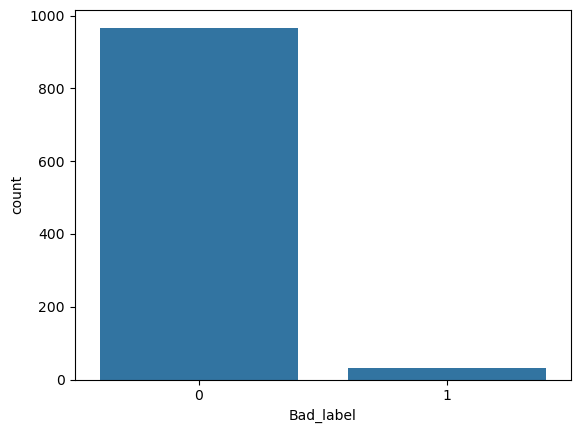

In [175]:
import seaborn as sns
sns.countplot(x='Bad_label', data=final_df)

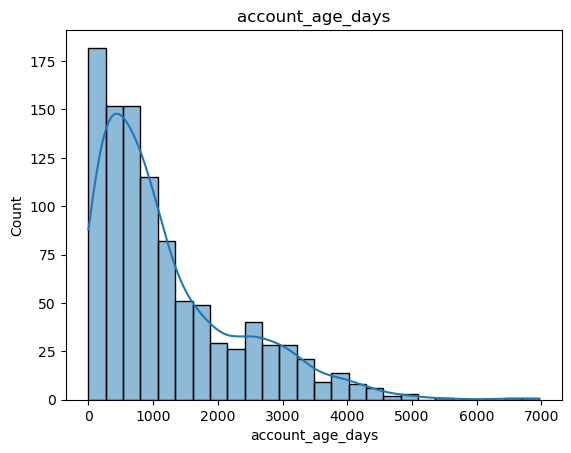

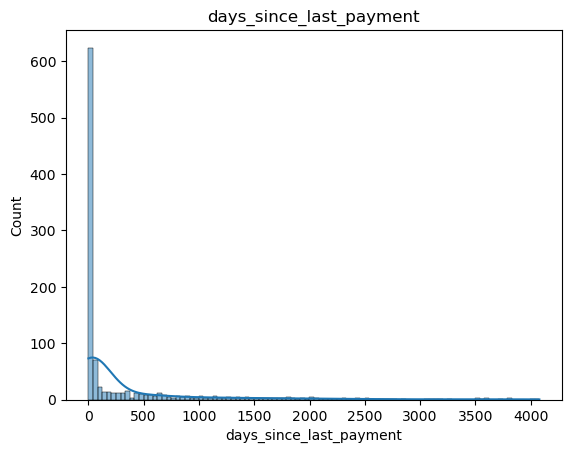

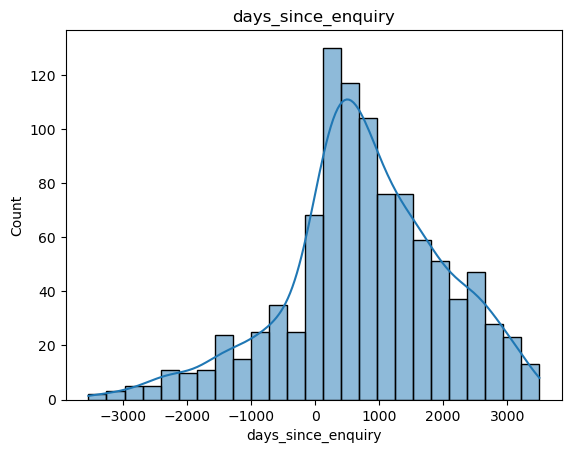

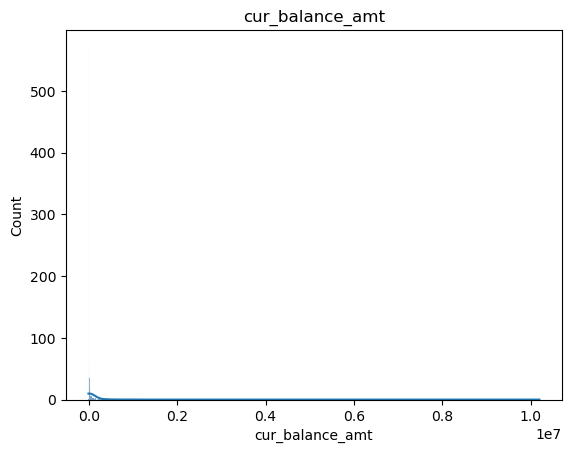

In [176]:
important_cols = ['account_age_days','days_since_last_payment','days_since_enquiry','cur_balance_amt']

for col in important_cols:
    sns.histplot(final_df[col], kde=True)
    plt.title(col)
    plt.show()

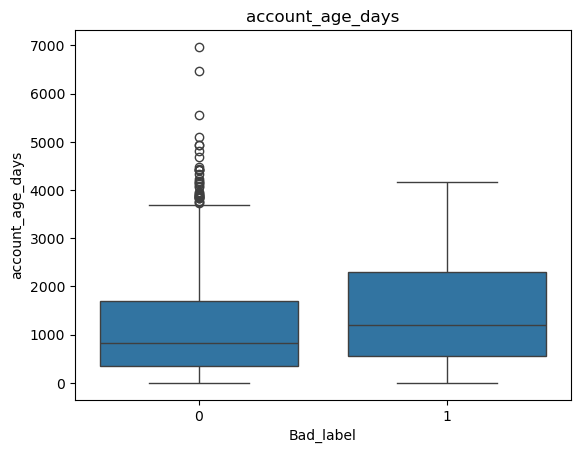

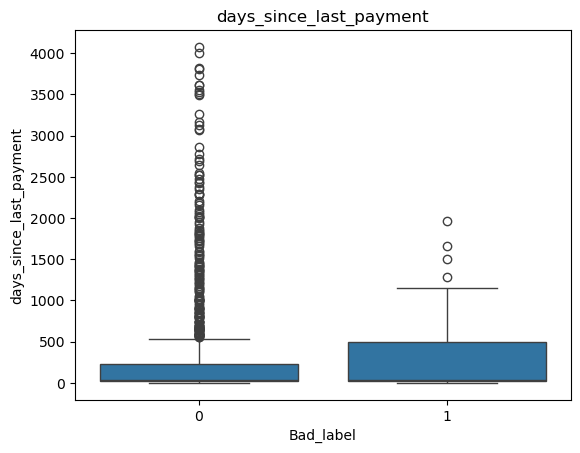

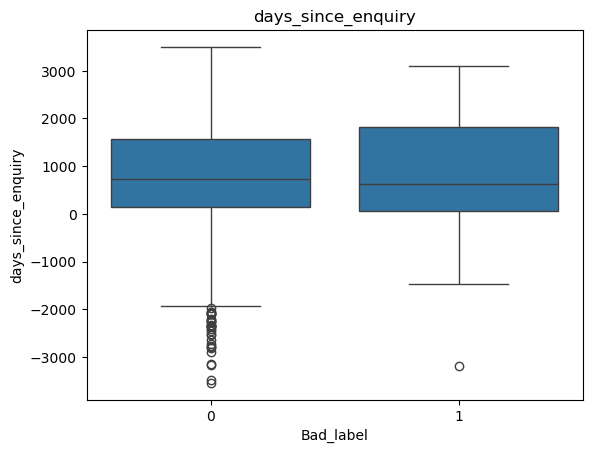

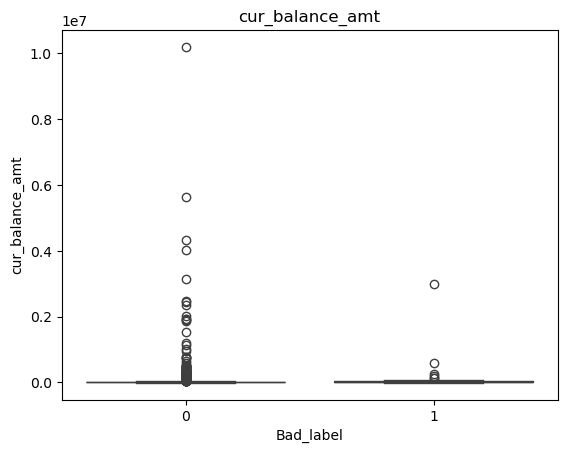

In [177]:
for col in important_cols:
    sns.boxplot(x='Bad_label', y=col, data=final_df)
    plt.title(col)
    plt.show()

In [178]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


# columns for outliers remove
for col in ['days_since_last_payment', 'cur_balance_amt']:
    if col in final_df.columns:
        final_df = remove_outliers(final_df, col)

print("Outliers removed")

Outliers removed


In [179]:
# Log transform (for skewed feature)
final_df['cur_balance_amt'] = np.log1p(final_df['cur_balance_amt'])

<Axes: ylabel='cur_balance_amt'>

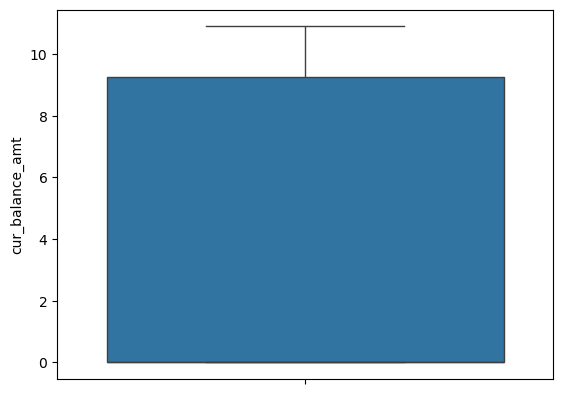

In [180]:
import seaborn as sns
sns.boxplot(final_df['cur_balance_amt'])

In [181]:
cat_cols = final_df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['feature_1', 'feature_5', 'feature_11', 'feature_12', 'feature_13',
       'feature_15', 'feature_16', 'feature_20', 'feature_22', 'feature_23',
       'feature_24', 'feature_27', 'feature_28', 'feature_32', 'feature_33',
       'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_45',
       'feature_46', 'feature_47', 'feature_50', 'feature_51', 'feature_58',
       'feature_59', 'feature_60', 'feature_62', 'feature_63', 'feature_70',
       'feature_72', 'feature_75', 'feature_77', 'feature_79',
       'paymenthistory1', 'paymenthistory2'],
      dtype='object')


In [182]:
final_df = pd.get_dummies(final_df, columns=cat_cols, drop_first=True)

In [183]:
final_df.dtypes.value_counts()

bool       3518
int64        33
float64      12
Name: count, dtype: int64

In [184]:
# Convert bool to int
bool_cols = final_df.select_dtypes(include='bool').columns

final_df[bool_cols] = final_df[bool_cols].astype(int)

In [185]:
final_df.dtypes.value_counts()

int32      3518
int64        33
float64      12
Name: count, dtype: int64

In [186]:
final_df = final_df.astype('float64')

In [187]:
final_df = final_df.fillna(0)

In [188]:
final_df.isnull().sum().sum()

0

# __Model Building__

In [189]:
X = final_df.drop(columns=['Bad_label'])
y = final_df['Bad_label']

In [190]:
X = X.replace([np.inf, -np.inf], np.nan)

In [191]:
X = X.fillna(0)

In [192]:
np.isinf(X).sum().sum()

0

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [194]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# __Model Training__

## __LogisticRegression__

In [195]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [196]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [197]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.27205882352941174


In [198]:
gini = 2 * roc_auc - 1
print("Gini Score:", gini)

Gini Score: -0.4558823529411765


In [199]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       136
         1.0       0.00      0.00      0.00         4

    accuracy                           0.97       140
   macro avg       0.49      0.50      0.49       140
weighted avg       0.94      0.97      0.96       140



In [200]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [201]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [202]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
gini = 2 * roc_auc - 1

print("ROC-AUC:", roc_auc)
print("Gini:", gini)

ROC-AUC: 0.3069852941176471
Gini: -0.38602941176470584


## __RandomForestClassifire__

In [203]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [204]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [205]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
gini_rf = 2 * roc_auc_rf - 1

print("RF ROC-AUC:", roc_auc_rf)
print("RF Gini:", gini_rf)

RF ROC-AUC: 0.6323529411764706
RF Gini: 0.2647058823529411


In [206]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       136
         1.0       0.00      0.00      0.00         4

    accuracy                           0.97       140
   macro avg       0.49      0.50      0.49       140
weighted avg       0.94      0.97      0.96       140



## __XGBClassifire__

In [207]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [208]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [209]:
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
gini_xgb = 2 * roc_auc_xgb - 1

print("XGB ROC-AUC:", roc_auc_xgb)
print("XGB Gini:", gini_xgb)

XGB ROC-AUC: 0.6158088235294118
XGB Gini: 0.2316176470588236


In [210]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       136
         1.0       0.00      0.00      0.00         4

    accuracy                           0.96       140
   macro avg       0.49      0.50      0.49       140
weighted avg       0.94      0.96      0.95       140



<Axes: >

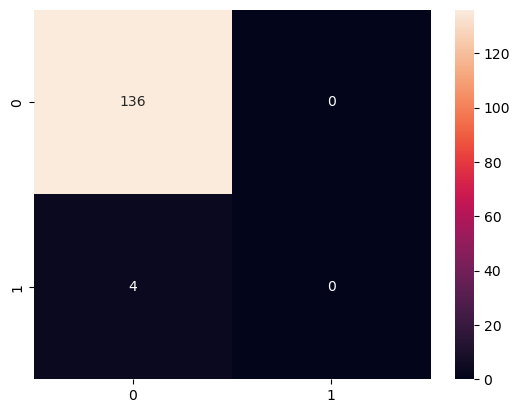

In [211]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')

In [212]:
df_pred = pd.DataFrame({
    'actual': y_test,
    'prob': y_prob_rf
})

In [213]:
df_pred['decile'] = pd.qcut(df_pred['prob'], 10, labels=False)

In [214]:
df_pred['decile'] = 10 - df_pred['decile']

In [215]:
df_pred

,actual,prob,decile
386,0.0,0.137049,7
433,0.0,0.187171,3
492,0.0,0.104145,9
166,0.0,0.131027,7
900,0.0,0.116400,8
578,0.0,0.190477,2
122,0.0,0.112591,8
849,0.0,0.104275,9
151,0.0,0.202576,2
768,0.0,0.123327,8


In [216]:
decile_table = df_pred.groupby('decile').agg(
    total=('actual', 'count'),
    bad=('actual', 'sum')
).reset_index()

In [217]:
decile_table['bad_rate'] = decile_table['bad'] / decile_table['total']

In [218]:
decile_table = decile_table.sort_values(by='decile', ascending=False)

In [219]:
decile_table

,decile,total,bad,bad_rate
9,10,14,0.0,0.000000
8,9,14,0.0,0.000000
7,8,14,1.0,0.071429
6,7,14,0.0,0.000000
5,6,14,0.0,0.000000
4,5,14,0.0,0.000000
3,4,14,0.0,0.000000
2,3,14,3.0,0.214286
1,2,14,0.0,0.000000
0,1,14,0.0,0.000000


* The decile analysis shows some instability in rank ordering due to the small number of default cases in the dataset. While the model captures certain patterns, limited minority class samples affect the consistency of decile distribution.

# __Save Model__

In [220]:
joblib.dump(rf_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [221]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [222]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [223]:
model_loaded = joblib.load("credit_risk_model.pkl")

In [224]:
model_loaded

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_